<a href="https://colab.research.google.com/github/ikyu-gnito/Projeto-integrador-2026/blob/main/TrabalhoProjetoIntegrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')


print("\nListing contents of the directory:")
!ls '/content/drive/MyDrive/Faculdade/Projeto integrador/banco.db'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Listing contents of the directory:
'/content/drive/MyDrive/Faculdade/Projeto integrador/banco.db'


In [ ]:
import sqlite3

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Como o arquivo é um banco de dados SQLite, conectamos a ele usando sqlite3
conexao = sqlite3.connect('/content/drive/MyDrive/Faculdade/Projeto integrador/banco.db')

# Lemos os dados da tabela 'atendimentos' diretamente para o DataFrame
df_original = pd.read_sql_query("SELECT * FROM atendimentos", conexao)

# Fecha a conexão após a leitura
conexao.close()

# Mostra os primeiros dados
df_original.head()

,id,atendimento_id,data_entrada,data_saida,servico,especialidade,diagnostico,cidade,bairro,sexo,data_nascimento
0,1,6368,2021-03-02T07:20:40.000Z,2021-03-02T11:02:00.000Z,CONSULTA,MEDICINA INTERNA/CLI,.NAO DEFINIDO.,ORIENTE,CARLOS VENDRAMINI,F,2000-05-07T00:00:00.000Z
1,2,2834,2020-12-22T09:03:43.000Z,2020-12-22T09:58:00.000Z,CONSULTA,MEDICINA INTERNA/CLI,.NAO DEFINIDO.,ORIENTE,CARLOS VENDRAMINI,F,2000-05-07T00:00:00.000Z
2,3,135118,2024-09-24T10:51:00.000Z,None,EXAMES,MEDICINA INTERNA/CLI,.NAO DEFINIDO.,POMPEIA,CENTRO,M,-799977600000
3,4,131485,2024-09-18T09:53:11.000Z,2024-09-18T10:22:00.000Z,CONSULTA,MEDICINA INTERNA/CLI,.NAO DEFINIDO.,POMPEIA,CENTRO,M,-799977600000
4,5,131121,2024-09-14T10:37:12.000Z,2024-09-14T17:35:00.000Z,CONSULTA,MEDICINA INTERNA/CLI,.NAO DEFINIDO.,POMPEIA,CENTRO,M,-799977600000


## Dashboard de Análise de Atendimentos

Nesta seção, consolidaremos algumas visualizações importantes a partir dos dados extraídos do seu banco de dados.

/tmp/ipykernel_5799/1432972876.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_original, y='especialidade', ax=axes[0, 0],
/tmp/ipykernel_5799/1432972876.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_original, x='servico', ax=axes[0, 1],
/tmp/ipykernel_5799/1432972876.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cidades.values, y=top_cidades.index, ax=axes[1, 1], palette='crest')


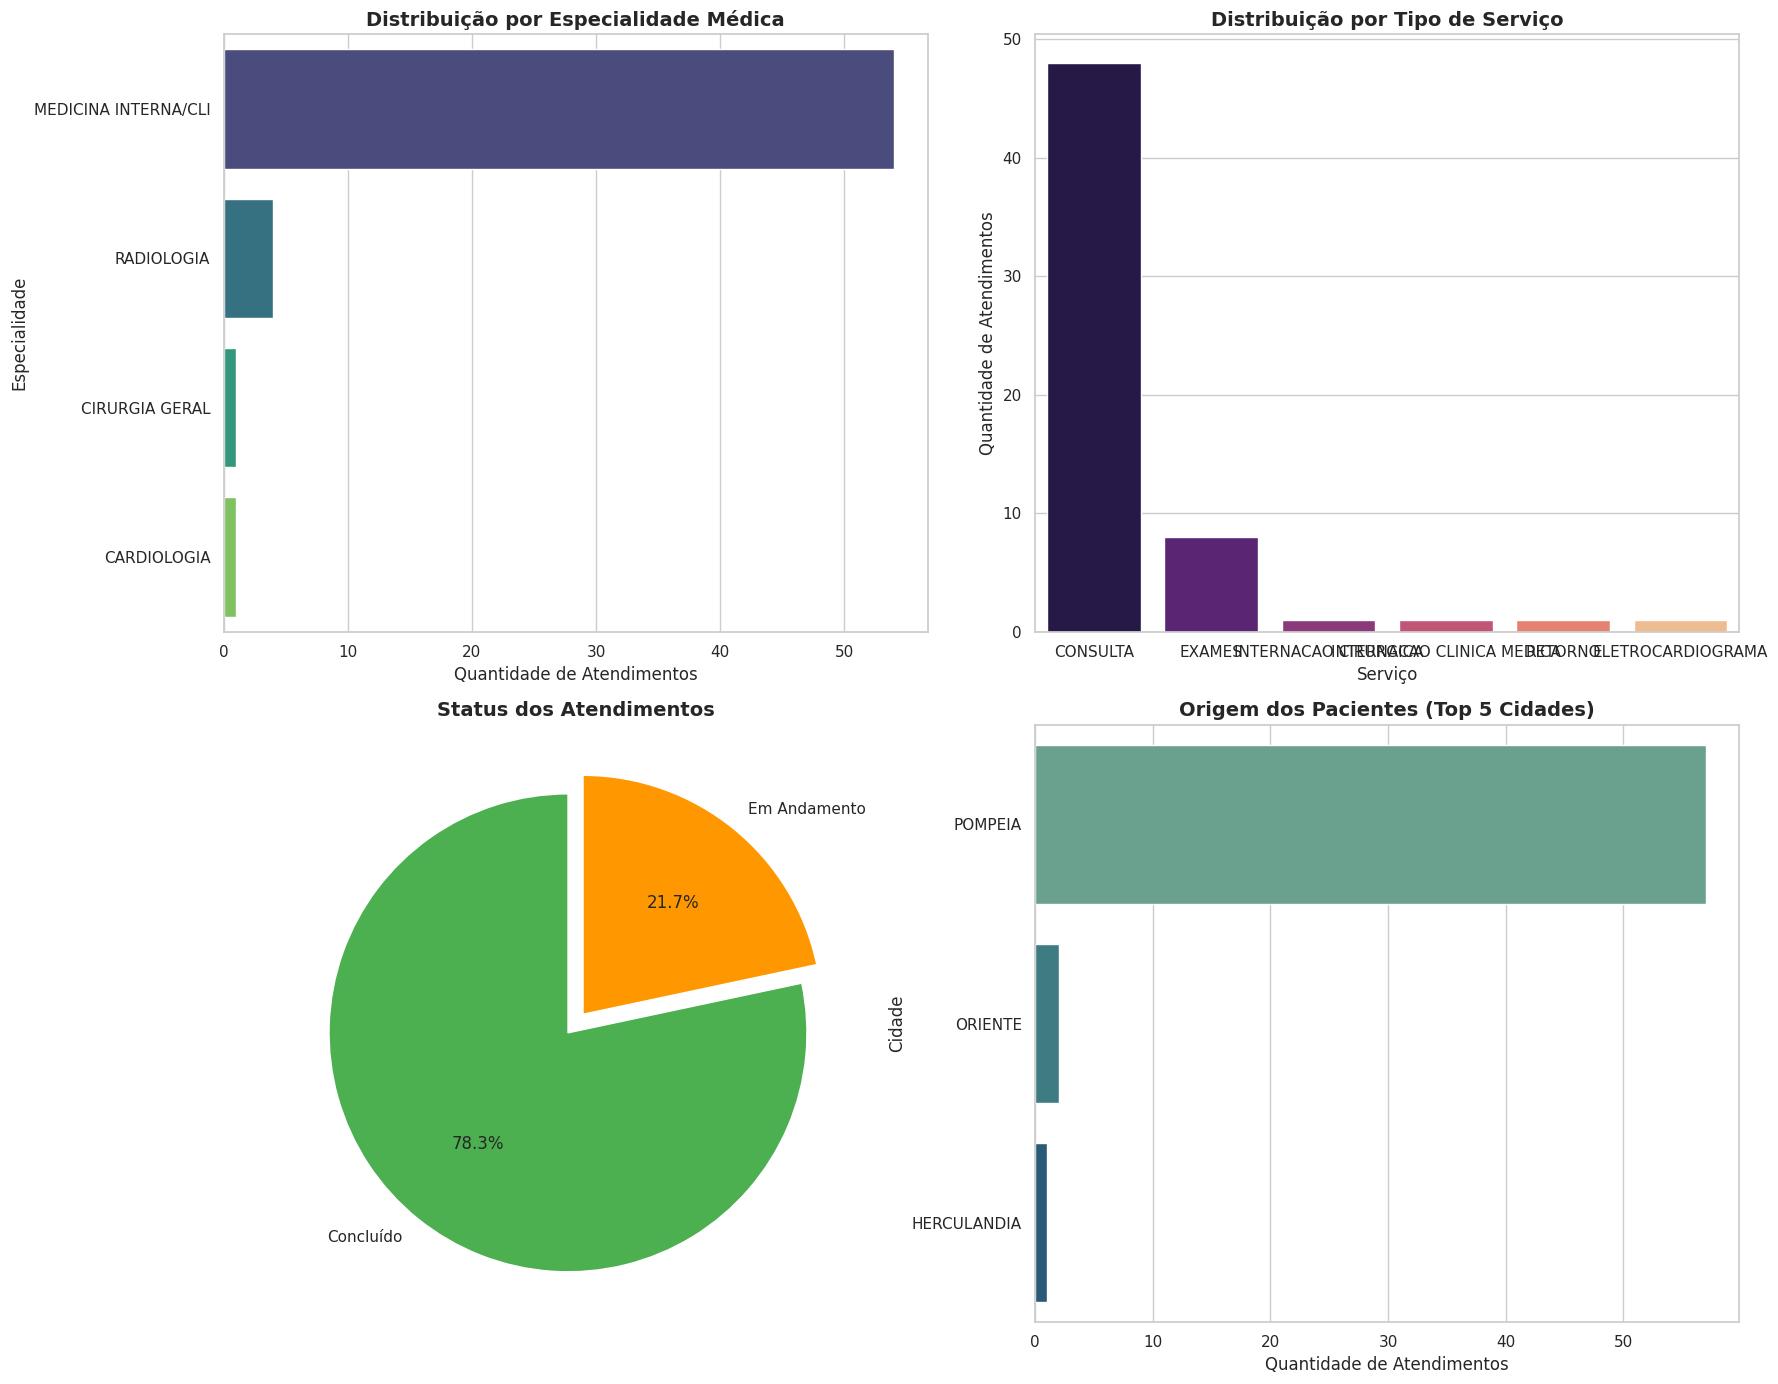

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração geral de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Criando a estrutura para múltiplos gráficos (2 linhas por 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Gráfico de Especialidades
sns.countplot(data=df_original, y='especialidade', ax=axes[0, 0],
              order=df_original['especialidade'].value_counts().index, palette='viridis')
axes[0, 0].set_title('Distribuição por Especialidade Médica', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Quantidade de Atendimentos')
axes[0, 0].set_ylabel('Especialidade')

# 2. Gráfico de Serviços
sns.countplot(data=df_original, x='servico', ax=axes[0, 1],
              order=df_original['servico'].value_counts().index, palette='magma')
axes[0, 1].set_title('Distribuição por Tipo de Serviço', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Serviço')
axes[0, 1].set_ylabel('Quantidade de Atendimentos')

# 3. Status do Atendimento (Concluído se tiver data de saída, senão Em Andamento)
df_original['status'] = df_original['data_saida'].apply(lambda x: 'Concluído' if pd.notna(x) and x != 'None' else 'Em Andamento')
status_counts = df_original['status'].value_counts()
axes[1, 0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
               colors=['#4CAF50', '#FF9800'], startangle=90, explode=(0.05, 0.05)[:len(status_counts)])
axes[1, 0].set_title('Status dos Atendimentos', fontsize=14, fontweight='bold')

# 4. Distribuição por Cidade (Top 5)
top_cidades = df_original['cidade'].value_counts().head(5)
sns.barplot(x=top_cidades.values, y=top_cidades.index, ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Origem dos Pacientes (Top 5 Cidades)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Quantidade de Atendimentos')
axes[1, 1].set_ylabel('Cidade')

plt.tight_layout()
plt.show()